# Synthetic Dataset Exploration and Model Benchmark

This notebook does two things in sequence:

1. Builds or reloads the new synthetic actuator anomaly dataset generated by the calibrated simulator.
2. Benchmarks every implemented model against both:
   - **binary anomaly detection** (`normal` vs `anomaly`)
   - **multiclass anomaly typing** (which anomaly class it is)

The benchmark covers:

- Logistic Regression
- XGBoost
- MLP Classifier
- Conv1D Classifier
- Conv1D Autoencoder for anomaly detection

In [1]:
from __future__ import annotations

import copy
import json
import pickle
import sys
import time
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(context='talk', style='whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

def locate_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'ml' / 'project.json').exists():
            return candidate
        if (candidate / 'starthack26' / 'ml' / 'project.json').exists():
            return candidate / 'starthack26'
    raise FileNotFoundError('Could not locate the starthack26 repo root from the current working directory.')

REPO_ROOT = locate_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml.data.etl import (
    RAW_TO_DISPLAY,
    build_calibration_reference,
    build_dataset_blob,
    build_synthetic_frame,
    load_config as load_data_config,
    parse_real_dataframe,
    prepare_dataframe,
    resolve_real_data_path,
    write_outputs,
)
from ml.models.arch import Model
from ml.models.train import (
    load_config as load_train_config,
    train_autoencoder,
    train_logistic_regression,
    train_conv1d_classifier,
    train_mlp_classifier,
    train_xgboost,
)

DATA_CONFIG_PATH = REPO_ROOT / 'ml/configs/data/default.yaml'
TRAIN_CONFIG_PATH = REPO_ROOT / 'ml/configs/train/default.yaml'
SYNTH_DATA_DIR = REPO_ROOT / 'ml/data/processed/synthetic_benchmark'
BENCHMARK_ARTIFACT_DIR = REPO_ROOT / 'ml/models/weights/synthetic_benchmark'
BENCHMARK_TENSORBOARD_DIR = REPO_ROOT / 'ml/tensorboard/synthetic_benchmark'
CLASS_SLUGS = list(RAW_TO_DISPLAY.keys())
CLASS_NAMES = [RAW_TO_DISPLAY[slug] for slug in CLASS_SLUGS]
MODEL_LABELS = {
    'logreg': 'Logistic Regression',
    'xgboost': 'XGBoost',
    'mlp_classifier': 'MLP Classifier',
    'conv1d_classifier': 'Conv1D Classifier',
    'conv1d_autoencoder': 'Conv1D Autoencoder',
}

REPO_ROOT

PosixPath('/Users/paulruiz/Documents/Starthack/starthack26')

## Build or load the synthetic benchmark dataset

The notebook writes benchmark-specific artifacts under:

- `ml/data/processed/synthetic_benchmark`
- `ml/models/weights/synthetic_benchmark`
- `ml/tensorboard/synthetic_benchmark`

In [2]:
if 'SYNTH_DATA_DIR' not in globals():
    raise RuntimeError('Run the setup cell above first so the notebook can locate the repo and initialize imports.')

FORCE_REBUILD_DATASET = True

SYNTH_DATA_DIR.mkdir(parents=True, exist_ok=True)
BENCHMARK_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
BENCHMARK_TENSORBOARD_DIR.mkdir(parents=True, exist_ok=True)

data_config = replace(
    load_data_config(str(DATA_CONFIG_PATH)),
    output_dir=str(SYNTH_DATA_DIR),
)

def ensure_synthetic_dataset(force_rebuild: bool = False):
    dataset_path = SYNTH_DATA_DIR / 'dataset.pt'
    csv_path = SYNTH_DATA_DIR / data_config.synthetic_csv_name
    metadata_path = SYNTH_DATA_DIR / data_config.metadata_name
    report_path = SYNTH_DATA_DIR / data_config.realism_report_name

    if force_rebuild or not all(path.exists() for path in [dataset_path, csv_path, metadata_path, report_path]):
        real_frame_local = parse_real_dataframe(resolve_real_data_path(data_config.real_data_path))
        calibration_reference = build_calibration_reference(real_frame_local, data_config)
        synthetic_frame_local = build_synthetic_frame(data_config, calibration_reference)
        dataset_blob_local, metadata_local, realism_report_local = build_dataset_blob(
            synthetic_frame_local,
            calibration_reference,
            data_config,
        )
        write_outputs(
            output_dir=SYNTH_DATA_DIR,
            synthetic_frame=synthetic_frame_local,
            dataset_blob=dataset_blob_local,
            metadata=metadata_local,
            realism_report=realism_report_local,
            config=data_config,
        )

    return (
        dataset_path,
        csv_path,
        metadata_path,
        report_path,
    )

dataset_path, synthetic_csv_path, metadata_path, realism_report_path = ensure_synthetic_dataset(
    force_rebuild=FORCE_REBUILD_DATASET,
)

dataset_blob = torch.load(dataset_path, map_location='cpu')
synthetic_df = prepare_dataframe(pd.read_csv(synthetic_csv_path), group_col='run_id')
synthetic_df['condition_name'] = synthetic_df['anomaly_type'].map(RAW_TO_DISPLAY)
synthetic_df['condition_family'] = np.where(synthetic_df['is_anomaly'].eq(1), 'Anomaly', 'Normal')
synthetic_df['abs_position_error_pct'] = synthetic_df['position_error_pct'].abs()
synthetic_df['abs_torque_Nmm'] = synthetic_df['motor_torque_Nmm'].abs()
synthetic_df['estimated_step_energy_J'] = synthetic_df['power_W'].clip(lower=0.0) * synthetic_df['effective_step_s']

real_df = parse_real_dataframe(resolve_real_data_path(data_config.real_data_path))
real_df['condition_name'] = real_df['anomaly_type'].map(RAW_TO_DISPLAY)
real_df['condition_family'] = np.where(real_df['is_anomaly'].eq(1), 'Anomaly', 'Normal')
real_df['abs_position_error_pct'] = real_df['position_error_pct'].abs()
real_df['abs_torque_Nmm'] = real_df['motor_torque_Nmm'].abs()
real_df['estimated_step_energy_J'] = real_df['power_W'].clip(lower=0.0) * real_df['effective_step_s']

metadata = json.loads(metadata_path.read_text())
realism_report = json.loads(realism_report_path.read_text())

split_names = np.empty(len(dataset_blob['run_ids']), dtype=object)
for split_name, indices in dataset_blob['split_indices'].items():
    split_names[indices.cpu().numpy()] = split_name

window_df = pd.DataFrame(
    {
        'run_id': dataset_blob['run_ids'],
        'split': split_names,
        'binary_label': dataset_blob['sequence_binary_labels'].cpu().numpy(),
        'class_id': dataset_blob['sequence_class_labels'].cpu().numpy(),
    }
)
window_df['condition_name'] = window_df['class_id'].map(dict(enumerate(dataset_blob['class_names'])))
window_df['condition_family'] = np.where(window_df['binary_label'].eq(1), 'Anomaly', 'Normal')

display(pd.DataFrame({'artifact': ['dataset.pt', 'synthetic CSV', 'metadata.json', 'realism_report.json'], 'path': [str(dataset_path), str(synthetic_csv_path), str(metadata_path), str(realism_report_path)]}))

,artifact,path
0,dataset.pt,/Users/paulruiz/Documents/Starthack/starthack2...
1,synthetic CSV,/Users/paulruiz/Documents/Starthack/starthack2...
2,metadata.json,/Users/paulruiz/Documents/Starthack/starthack2...
3,realism_report.json,/Users/paulruiz/Documents/Starthack/starthack2...


## Dataset overview

In [3]:
overview = pd.DataFrame(
    {
        'row_count': [len(synthetic_df)],
        'run_count': [synthetic_df['run_id'].nunique()],
        'window_count': [len(window_df)],
        'sequence_window_size': [metadata['sequence_window_size']],
        'window_stride': [metadata['window_stride']],
        'real_source_rows': [len(real_df)],
        'real_source_runs': [real_df['run_id'].nunique()],
    }
)

row_balance = synthetic_df.groupby(['split', 'condition_name']).size().unstack(fill_value=0).reindex(columns=CLASS_NAMES)
run_balance = synthetic_df.groupby(['split', 'condition_name'])['run_id'].nunique().unstack(fill_value=0).reindex(columns=CLASS_NAMES)
window_balance = window_df.groupby(['split', 'condition_name']).size().unstack(fill_value=0).reindex(columns=CLASS_NAMES)

display(overview)
display(Markdown('### Row balance by split'))
display(row_balance)
display(Markdown('### Run balance by split'))
display(run_balance)
display(Markdown('### Window balance by split'))
display(window_balance)

,row_count,run_count,window_count,sequence_window_size,window_stride,real_source_rows,real_source_runs
0,307201,1200,15025,64,16,4470,6


### Row balance by split

condition_name,Normal Operation,Valve Destabilization (Repeated Poking),Closure Blockage (Bottle Held Open),Gear Jam / Transmission Lock,Added Mechanical Resistance
split,,,,,
test,9020,8954,8900,9239,9288
train,43273,42628,42909,43605,43281
val,9573,8944,9302,9212,9073


### Run balance by split

condition_name,Normal Operation,Valve Destabilization (Repeated Poking),Closure Blockage (Bottle Held Open),Gear Jam / Transmission Lock,Added Mechanical Resistance
split,,,,,
test,36,36,36,36,36
train,168,168,168,168,168
val,36,36,36,36,36


### Window balance by split

condition_name,Normal Operation,Valve Destabilization (Repeated Poking),Closure Blockage (Bottle Held Open),Gear Jam / Transmission Lock,Added Mechanical Resistance
split,,,,,
test,1390,196,183,211,239
train,6616,965,1013,906,1048
val,1447,206,198,172,235


## Real vs synthetic realism summary

In [4]:
realism_overview = pd.DataFrame(
    [
        {
            'dataset': 'real',
            'window_count': realism_report['reference']['real_window_count'],
            'participation_ratio': realism_report['reference']['participation_ratio'],
            'knn_mean_distance': realism_report['reference']['knn_distance']['mean'],
            'knn_median_distance': realism_report['reference']['knn_distance']['median'],
        },
        {
            'dataset': 'synthetic',
            'window_count': realism_report['synthetic']['window_count'],
            'participation_ratio': realism_report['synthetic']['participation_ratio'],
            'knn_mean_distance': realism_report['synthetic']['knn_distance']['mean'],
            'knn_median_distance': realism_report['synthetic']['knn_distance']['median'],
        },
    ]
)

realism_gap = pd.Series(
    {
        'pca_gap_l2': realism_report['pca_gap_l2'],
        'mmd_rbf': realism_report['mmd_rbf'],
        'real_to_synthetic_neighbor_mix': realism_report['neighborhood_mixing']['real_to_synthetic'],
        'synthetic_to_real_neighbor_mix': realism_report['neighborhood_mixing']['synthetic_to_real'],
    },
    name='realism_gap',
)

ks_df = pd.DataFrame(realism_report['feature_ks']).T.sort_values('statistic', ascending=False)

def summarize_by_class(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby('condition_name')
        .agg(
            mean_power_W=('power_W', 'mean'),
            mean_abs_torque_Nmm=('abs_torque_Nmm', 'mean'),
            median_abs_position_error_pct=('abs_position_error_pct', 'median'),
            mean_temperature_C=('internal_temperature_deg_C', 'mean'),
            mean_velocity_pct_per_s=('velocity_pct_per_s', 'mean'),
        )
        .reindex(CLASS_NAMES)
        .round(4)
    )

comparison_summary = pd.concat(
    {
        'real': summarize_by_class(real_df),
        'synthetic': summarize_by_class(synthetic_df),
    },
    axis=1,
)

display(realism_overview)
display(realism_gap.to_frame())
display(Markdown('### Top KS gaps between real and synthetic window features'))
display(ks_df.head(12))
display(Markdown('### Class summary: real vs synthetic'))
display(comparison_summary)

,dataset,window_count,participation_ratio,knn_mean_distance,knn_median_distance
0,real,259,2.1560,3.7236,3.5938
1,synthetic,15025,2.9042,8.2035,7.9619


,realism_gap
pca_gap_l2,0.1763
mmd_rbf,0.3667
real_to_synthetic_neighbor_mix,0.1290
synthetic_to_real_neighbor_mix,0.1761


### Top KS gaps between real and synthetic window features

,statistic,pvalue
pipe_air_temperature_deg_C__min,0.9846,0.0000
pipe_air_temperature_ema_8__min,0.9730,0.0000
pipe_air_temperature_deg_C__mean,0.9344,0.0000
pipe_air_temperature_ema_8__mean,0.9344,0.0000
pipe_air_temperature_ema_8__max,0.8571,0.0000
pipe_air_temperature_deg_C__max,0.8378,0.0000
pipe_air_flow_ema_8__std,0.7606,0.0000
power_W__std,0.7568,0.0000
power_W__max,0.7143,0.0000
pipe_air_flow_Lpm__std,0.6718,0.0000


### Class summary: real vs synthetic

real                      \
                                        mean_power_W mean_abs_torque_Nmm   
condition_name                                                             
Normal Operation                              0.1673              0.5987   
Valve Destabilization (Repeated Poking)       0.1283              0.4162   
Closure Blockage (Bottle Held Open)           0.1788              0.6278   
Gear Jam / Transmission Lock                  0.0042              0.0491   
Added Mechanical Resistance                   0.2205              0.7393   

                                                                       \
                                        median_abs_position_error_pct   
condition_name                                                          
Normal Operation                                              23.0528   
Valve Destabilization (Repeated Poking)                        7.9145   
Closure Blockage (Bottle Held Open)                           32.6610   
Gear Jam / Transmission Lock                                   1.7500   
Added Mechanical Resistance                                   31.4550   

                                                            \
                                        mean_temperature_C   
condition_name                                               
Normal Operation                                   27.0614   
Valve Destabilization (Repeated Poking)            27.5951   
Closure Blockage (Bottle Held Open)                27.1734   
Gear Jam / Transmission Lock                       26.8684   
Added Mechanical Resistance                        27.8483   

                                                                   synthetic  \
                                        mean_velocity_pct_per_s mean_power_W   
condition_name                                                                 
Normal Operation                                        -0.0137       0.1149   
Valve Destabilization (Repeated Poking)                  0.5650       0.1092   
Closure Blockage (Bottle Held Open)                      0.6251       0.1288   
Gear Jam / Transmission Lock                            -0.0346       0.0799   
Added Mechanical Resistance                              1.3929       0.1167   

                                                             \
                                        mean_abs_torque_Nmm   
condition_name                                                
Normal Operation                                     0.4618   
Valve Destabilization (Repeated Poking)              0.4679   
Closure Blockage (Bottle Held Open)                  0.5652   
Gear Jam / Transmission Lock                         0.3396   
Added Mechanical Resistance                          0.5841   

                                                                       \
                                        median_abs_position_error_pct   
condition_name                                                          
Normal Operation                                              12.2194   
Valve Destabilization (Repeated Poking)                       10.6857   
Closure Blockage (Bottle Held Open)                           13.1039   
Gear Jam / Transmission Lock                                  28.9239   
Added Mechanical Resistance                                   25.3097   

                                                            \
                                        mean_temperature_C   
condition_name                                               
Normal Operation                                   27.1952   
Valve Destabilization (Repeated Poking)            27.3554   
Closure Blockage (Bottle Held Open)                27.2304   
Gear Jam / Transmission Lock                       27.1206   
Added Mechanical Resistance                        27.4424   

                                                                 
                                        mean_velocity_pct_per_s

## Synthetic row-level distributions by class

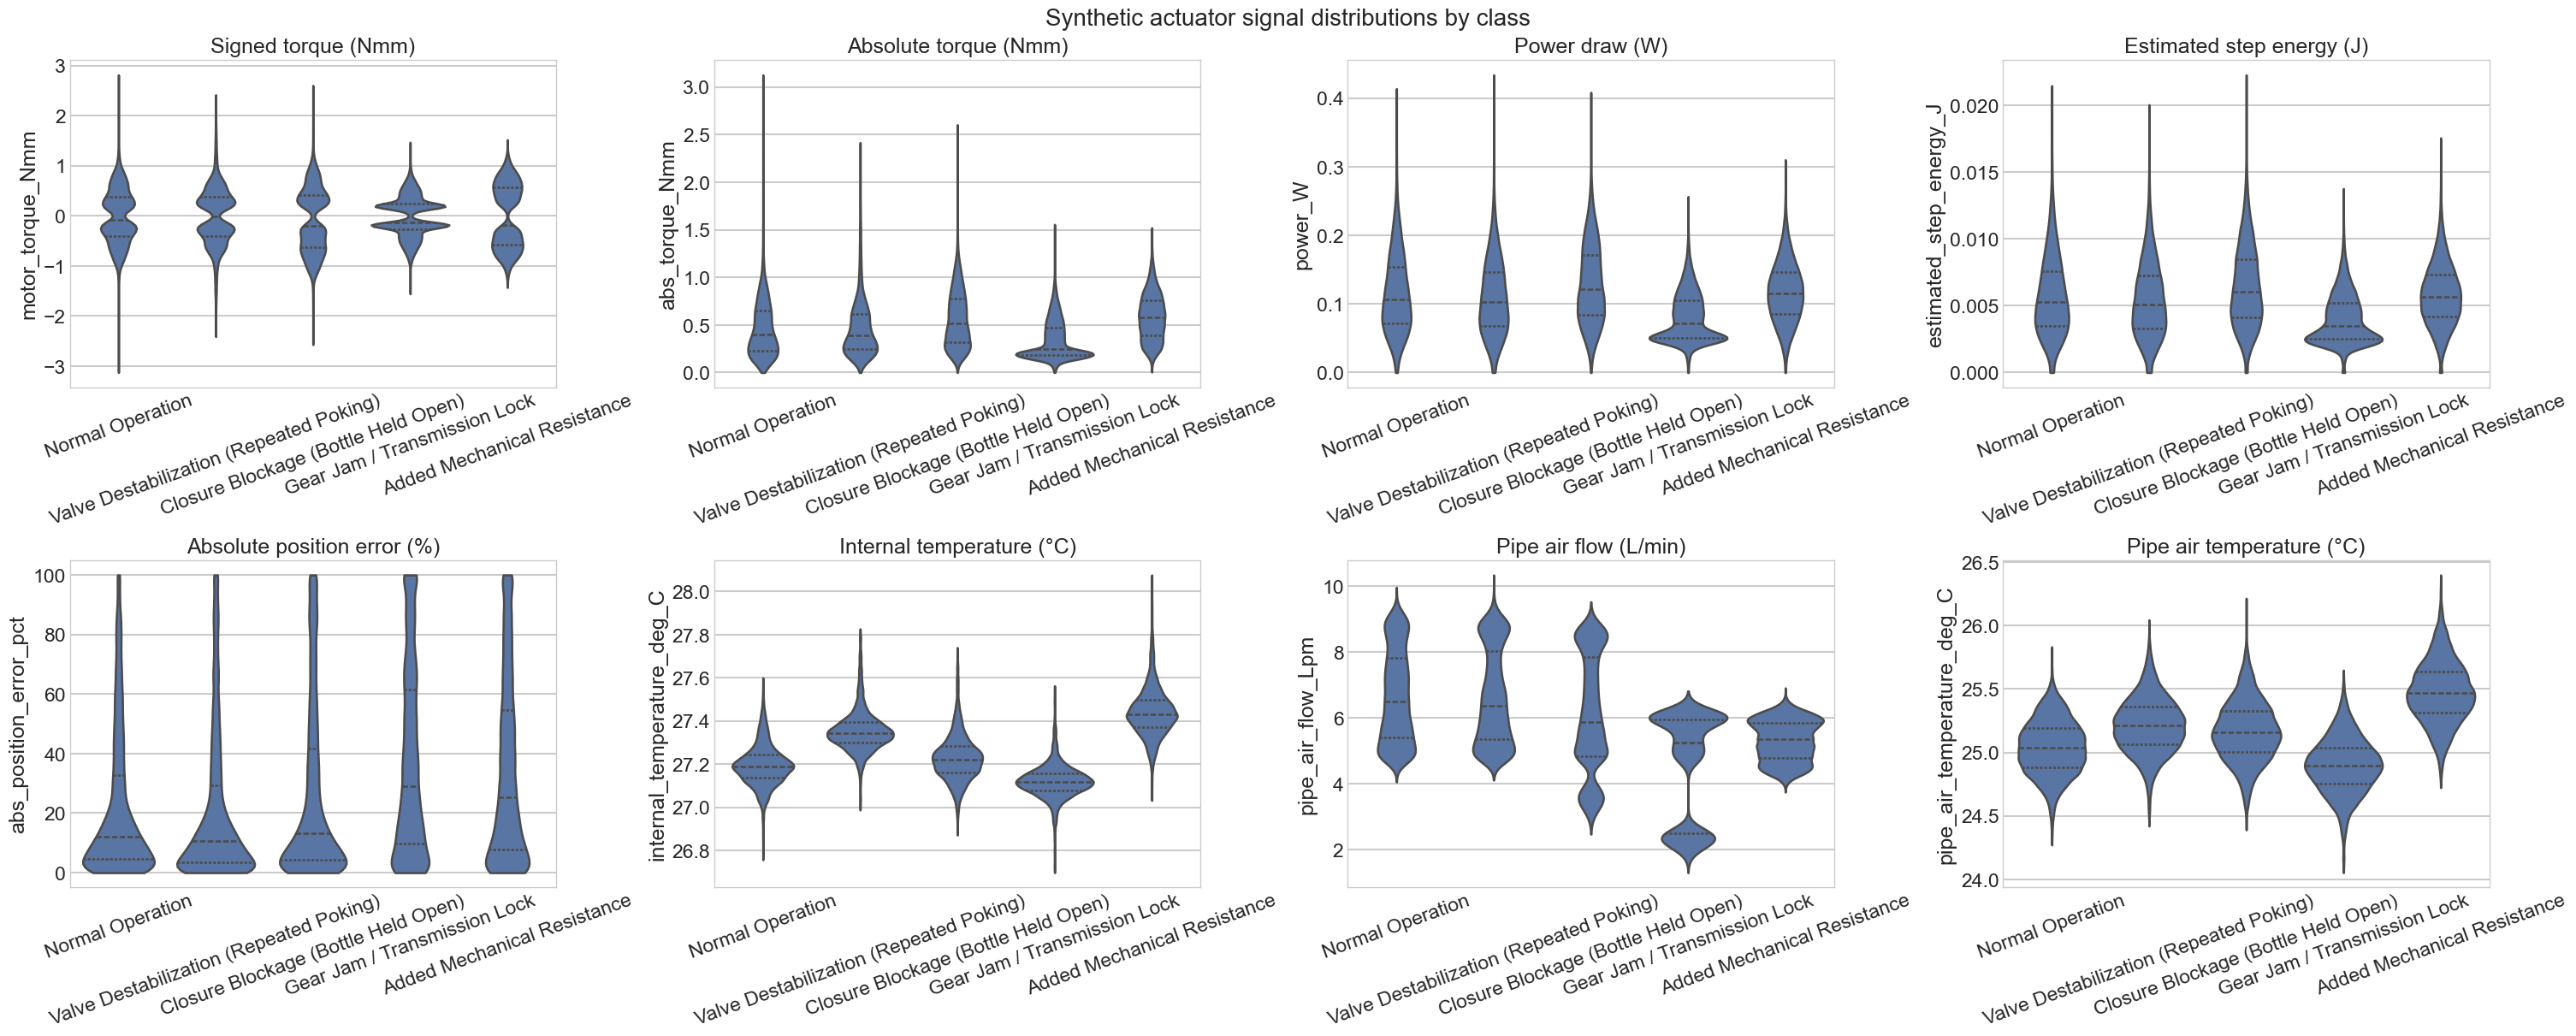

In [5]:
metric_titles = {
    'motor_torque_Nmm': 'Signed torque (Nmm)',
    'abs_torque_Nmm': 'Absolute torque (Nmm)',
    'power_W': 'Power draw (W)',
    'estimated_step_energy_J': 'Estimated step energy (J)',
    'abs_position_error_pct': 'Absolute position error (%)',
    'internal_temperature_deg_C': 'Internal temperature (°C)',
    'pipe_air_flow_Lpm': 'Pipe air flow (L/min)',
    'pipe_air_temperature_deg_C': 'Pipe air temperature (°C)',
}

fig, axes = plt.subplots(2, 4, figsize=(30, 12), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, metric_titles.items()):
    sns.violinplot(
        data=synthetic_df,
        x='condition_name',
        y=metric,
        order=CLASS_NAMES,
        inner='quartile',
        cut=0,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Synthetic actuator signal distributions by class', fontsize=20)
plt.show()

## Representative synthetic traces per class

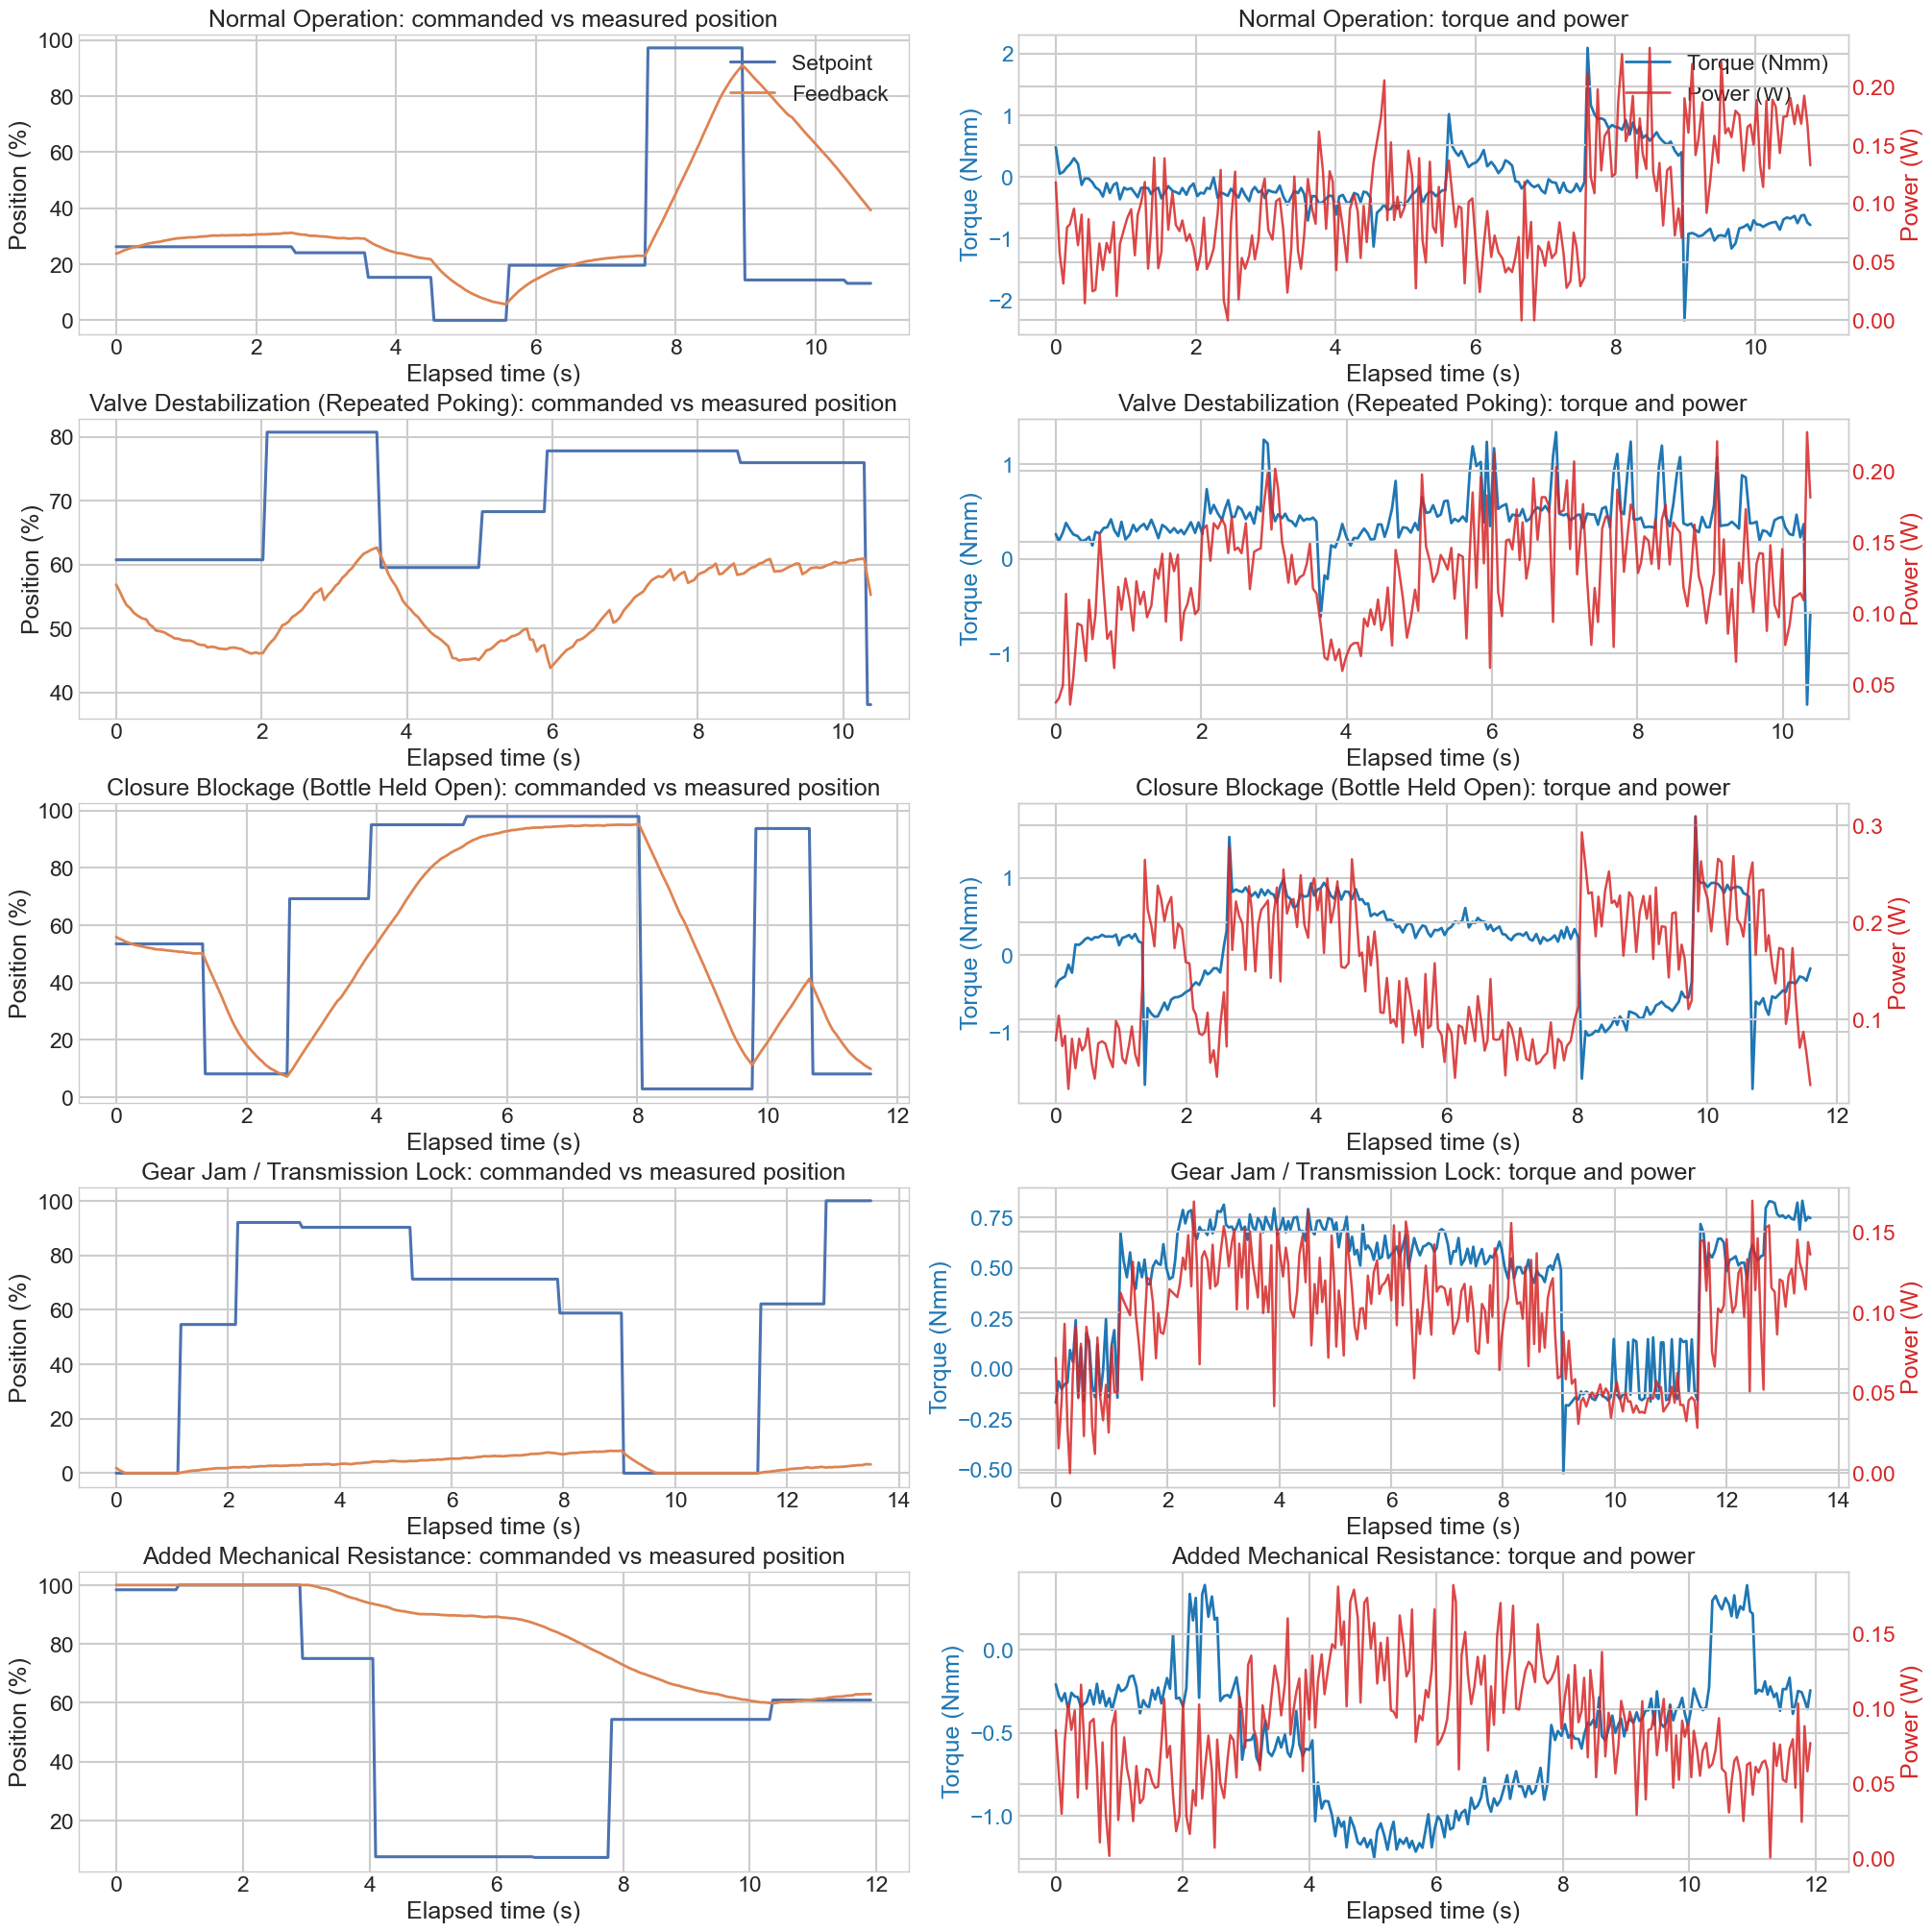

In [6]:
representative_runs = (
    synthetic_df.sort_values(['condition_name', 'run_id', '_time'])
    .groupby('condition_name')['run_id']
    .first()
    .reindex(CLASS_NAMES)
)

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(20, 4 * len(CLASS_NAMES)), constrained_layout=True)

for row, condition_name in enumerate(CLASS_NAMES):
    run_id = representative_runs.loc[condition_name]
    trace = synthetic_df[synthetic_df['run_id'] == run_id].sort_values('_time').copy()
    trace['elapsed_s'] = (trace['_time'] - trace['_time'].min()).dt.total_seconds()

    ax_left = axes[row, 0]
    ax_left.plot(trace['elapsed_s'], trace['setpoint_position_%'], label='Setpoint', linewidth=2.2)
    ax_left.plot(trace['elapsed_s'], trace['feedback_position_%'], label='Feedback', linewidth=2.0)
    ax_left.set_title(f'{condition_name}: commanded vs measured position')
    ax_left.set_xlabel('Elapsed time (s)')
    ax_left.set_ylabel('Position (%)')
    if row == 0:
        ax_left.legend(loc='upper right')

    ax_right = axes[row, 1]
    torque_line = ax_right.plot(trace['elapsed_s'], trace['motor_torque_Nmm'], color='tab:blue', label='Torque (Nmm)', linewidth=2.0)
    ax_right.set_xlabel('Elapsed time (s)')
    ax_right.set_ylabel('Torque (Nmm)', color='tab:blue')
    ax_right.tick_params(axis='y', labelcolor='tab:blue')
    ax_right.set_title(f'{condition_name}: torque and power')

    power_axis = ax_right.twinx()
    power_line = power_axis.plot(trace['elapsed_s'], trace['power_W'], color='tab:red', label='Power (W)', linewidth=1.8, alpha=0.85)
    power_axis.set_ylabel('Power (W)', color='tab:red')
    power_axis.tick_params(axis='y', labelcolor='tab:red')

    if row == 0:
        lines = torque_line + power_line
        ax_right.legend(lines, [line.get_label() for line in lines], loc='upper right')

plt.show()

## 3D PCA of synthetic windows

In [7]:
rng = np.random.default_rng(42)
available_windows = min(len(window_df), int(dataset_blob['tabular_features'].shape[0]))
if available_windows < 3:
    raise ValueError('Need at least 3 synthetic windows to compute a 3D PCA projection.')

sample_size = min(5000, available_windows)
sample_idx = rng.choice(available_windows, size=sample_size, replace=False)

sampled_features = dataset_blob['tabular_features'].cpu().numpy()[sample_idx]
sampled_windows = window_df.iloc[sample_idx].reset_index(drop=True)

scaled = StandardScaler().fit_transform(sampled_features)
pca = PCA(n_components=3, random_state=42)
components = pca.fit_transform(scaled)

pca_df = sampled_windows.copy()
pca_df[['PC1', 'PC2', 'PC3']] = components
labels = {
    'PC1': f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
    'PC2': f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
    'PC3': f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
}

fig_family = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='condition_family',
    opacity=0.65,
    hover_data=['condition_name', 'split', 'run_id'],
    labels=labels,
    title='Synthetic window PCA: Normal vs Anomaly',
    color_discrete_sequence=px.colors.qualitative.Safe,
)
fig_family.update_traces(marker=dict(size=3))
fig_family.update_layout(height=700)
fig_family.show()

fig_class = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='condition_name',
    opacity=0.65,
    hover_data=['condition_family', 'split', 'run_id'],
    labels=labels,
    title='Synthetic window PCA: all classes',
    color_discrete_sequence=px.colors.qualitative.Safe,
)
fig_class.update_traces(marker=dict(size=3))
fig_class.update_layout(height=700)
fig_class.show()

anomaly_pca_df = pca_df[pca_df['condition_family'].eq('Anomaly')].copy()
if not anomaly_pca_df.empty:
    fig_anomaly = px.scatter_3d(
        anomaly_pca_df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='condition_name',
        opacity=0.65,
        hover_data=['split', 'run_id'],
        labels=labels,
        title='Synthetic window PCA: anomaly types only',
        color_discrete_sequence=px.colors.qualitative.Safe,
    )
    fig_anomaly.update_traces(marker=dict(size=3))
    fig_anomaly.update_layout(height=700)
    fig_anomaly.show()

pd.Series(pca.explained_variance_ratio_, index=['PC1', 'PC2', 'PC3'], name='explained_variance_ratio').round(4)

PC1   0.1606
PC2   0.1563
PC3   0.1250
Name: explained_variance_ratio, dtype: float32

## Benchmark all model modes on the synthetic dataset

The benchmark caches artifacts under `ml/models/weights/synthetic_benchmark` so rerunning the notebook does not retrain unless `FORCE_RETRAIN_MODELS` is set to `True`.

In [8]:
FORCE_RETRAIN_MODELS = True
benchmark_plan = [
    ('binary', 'logreg'),
    ('binary', 'xgboost'),
    ('binary', 'mlp_classifier'),
    ('binary', 'conv1d_classifier'),
    ('autoencoder', 'conv1d_autoencoder'),
    ('multiclass', 'logreg'),
    ('multiclass', 'xgboost'),
    ('multiclass', 'mlp_classifier'),
    ('multiclass', 'conv1d_classifier'),
]

train_config = load_train_config(str(TRAIN_CONFIG_PATH))
train_config = copy.deepcopy(train_config)
train_config['artifact_dir'] = str(BENCHMARK_ARTIFACT_DIR)
train_config['tensorboard_dir'] = str(BENCHMARK_TENSORBOARD_DIR)

def artifact_path_for(model_type: str, task: str) -> Path:
    suffix = '.pt' if model_type in {'mlp_classifier', 'conv1d_classifier', 'conv1d_autoencoder'} else '.pkl'
    return BENCHMARK_ARTIFACT_DIR / f'{model_type}_{task}{suffix}'

def metrics_path_for(artifact_path: Path) -> Path:
    return artifact_path.with_name(f'{artifact_path.stem}_metrics.json')

def save_pickle_artifact(path: Path, artifact) -> None:
    with open(path, 'wb') as handle:
        pickle.dump(artifact, handle)

def load_artifact(path: Path):
    if path.suffix == '.pt':
        return torch.load(path, map_location='cpu', weights_only=False)
    with open(path, 'rb') as handle:
        return pickle.load(handle)

def train_or_load(task: str, model_type: str):
    artifact_path = artifact_path_for(model_type, task)
    metrics_path = metrics_path_for(artifact_path)

    if artifact_path.exists() and metrics_path.exists() and not FORCE_RETRAIN_MODELS:
        return load_artifact(artifact_path), json.loads(metrics_path.read_text())

    config = copy.deepcopy(train_config)
    torch.manual_seed(int(config['seed']))
    np.random.seed(int(config['seed']))
    started = time.perf_counter()

    if model_type == 'logreg':
        artifact, metrics = train_logistic_regression(dataset_blob, config, task)
        save_pickle_artifact(artifact_path, artifact)
    elif model_type == 'xgboost':
        artifact, metrics = train_xgboost(dataset_blob, config, task)
        save_pickle_artifact(artifact_path, artifact)
    elif model_type == 'mlp_classifier':
        artifact, metrics = train_mlp_classifier(dataset_blob, config, task, artifact_path)
    elif model_type == 'conv1d_classifier':
        artifact, metrics = train_conv1d_classifier(dataset_blob, config, task, artifact_path)
    elif model_type == 'conv1d_autoencoder':
        artifact, metrics = train_autoencoder(dataset_blob, config, artifact_path)
    else:
        raise ValueError(f'Unsupported model_type: {model_type}')

    metrics['fit_seconds'] = time.perf_counter() - started
    metrics['artifact_path'] = str(artifact_path)
    metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    return artifact, metrics

benchmark_artifacts = {}
benchmark_metrics = {}
for task, model_type in benchmark_plan:
    artifact, metrics = train_or_load(task, model_type)
    benchmark_artifacts[(task, model_type)] = artifact
    benchmark_metrics[(task, model_type)] = metrics

runtime_df = pd.DataFrame(
    [
        {
            'task': task,
            'model': MODEL_LABELS[model_type],
            'fit_seconds': benchmark_metrics[(task, model_type)].get('fit_seconds', np.nan),
            'artifact_path': benchmark_metrics[(task, model_type)].get('artifact_path', ''),
        }
        for task, model_type in benchmark_plan
    ]
).sort_values(['task', 'fit_seconds'])

display(runtime_df)

,task,model,fit_seconds,artifact_path
4,autoencoder,Conv1D Autoencoder,74.3518,/Users/paulruiz/Documents/Starthack/starthack2...
0,binary,Logistic Regression,0.1078,/Users/paulruiz/Documents/Starthack/starthack2...
1,binary,XGBoost,0.7098,/Users/paulruiz/Documents/Starthack/starthack2...
2,binary,MLP Classifier,1.7213,/Users/paulruiz/Documents/Starthack/starthack2...
3,binary,Conv1D Classifier,96.8732,/Users/paulruiz/Documents/Starthack/starthack2...
5,multiclass,Logistic Regression,0.2554,/Users/paulruiz/Documents/Starthack/starthack2...
7,multiclass,MLP Classifier,1.0513,/Users/paulruiz/Documents/Starthack/starthack2...
6,multiclass,XGBoost,2.9154,/Users/paulruiz/Documents/Starthack/starthack2...
8,multiclass,Conv1D Classifier,95.0021,/Users/paulruiz/Documents/Starthack/starthack2...


## Evaluation helpers

In [9]:
TEST_TABULAR_X = dataset_blob['tabular_features'][dataset_blob['split_indices']['test']].cpu().numpy()
TEST_BINARY_Y = dataset_blob['tabular_binary_labels'][dataset_blob['split_indices']['test']].cpu().numpy()
TEST_MULTI_Y = dataset_blob['tabular_class_labels'][dataset_blob['split_indices']['test']].cpu().numpy()
TEST_SEQUENCE_X = dataset_blob['sequence_windows'][dataset_blob['split_indices']['test']].cpu()
TEST_SEQUENCE_BINARY_Y = dataset_blob['sequence_binary_labels'][dataset_blob['split_indices']['test']].cpu().numpy()
CLASS_LABEL_INDICES = list(range(len(CLASS_NAMES)))

def preprocess_mlp_features(features: np.ndarray, checkpoint: dict) -> np.ndarray:
    stats = np.array(checkpoint['imputer_statistics'], dtype=np.float32)
    mean = np.array(checkpoint['scaler_mean'], dtype=np.float32)
    scale = np.array(checkpoint['scaler_scale'], dtype=np.float32)
    safe_scale = np.where(np.abs(scale) < 1e-6, 1.0, scale)
    filled = np.where(np.isnan(features), stats, features)
    transformed = (filled - mean) / safe_scale
    return np.nan_to_num(transformed, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def evaluate_binary_predictions(model_label: str, y_true: np.ndarray, y_pred: np.ndarray, scores: np.ndarray) -> dict:
    unique = np.unique(y_true)
    return {
        'model': model_label,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, scores) if len(unique) > 1 else np.nan,
        'pr_auc': average_precision_score(y_true, scores) if len(unique) > 1 else np.nan,
    }

def evaluate_multiclass_predictions(model_label: str, y_true: np.ndarray, y_pred: np.ndarray) -> tuple[dict, dict, np.ndarray]:
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_LABEL_INDICES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    summary = {
        'model': model_label,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
    }
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABEL_INDICES)
    return summary, report, cm

def evaluate_logreg(artifact, task: str):
    probabilities = artifact.predict_proba(TEST_TABULAR_X)
    predictions = artifact.predict(TEST_TABULAR_X)
    if task == 'binary':
        return evaluate_binary_predictions(MODEL_LABELS['logreg'], TEST_BINARY_Y, predictions, probabilities[:, 1]), confusion_matrix(TEST_BINARY_Y, predictions, labels=[0, 1]), classification_report(TEST_BINARY_Y, predictions, labels=[0, 1], target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    return evaluate_multiclass_predictions(MODEL_LABELS['logreg'], TEST_MULTI_Y, predictions)

def evaluate_xgboost(artifact, task: str):
    transformed = artifact['imputer'].transform(TEST_TABULAR_X)
    probabilities = artifact['model'].predict_proba(transformed)
    predictions = artifact['model'].predict(transformed).astype(int)
    if task == 'binary':
        return evaluate_binary_predictions(MODEL_LABELS['xgboost'], TEST_BINARY_Y, predictions, probabilities[:, 1]), confusion_matrix(TEST_BINARY_Y, predictions, labels=[0, 1]), classification_report(TEST_BINARY_Y, predictions, labels=[0, 1], target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    return evaluate_multiclass_predictions(MODEL_LABELS['xgboost'], TEST_MULTI_Y, predictions)

def evaluate_mlp(checkpoint: dict, task: str):
    transformed = preprocess_mlp_features(TEST_TABULAR_X, checkpoint)
    model = Model(
        model_type='mlp_classifier',
        input_dim=int(checkpoint['input_dim']),
        hidden_dim=int(checkpoint['hidden_dim']),
        num_classes=int(checkpoint['num_classes']),
        dropout=float(checkpoint['dropout']),
    )
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(transformed, dtype=torch.float32))
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predictions = probabilities.argmax(axis=1)
    if task == 'binary':
        return evaluate_binary_predictions(MODEL_LABELS['mlp_classifier'], TEST_BINARY_Y, predictions, probabilities[:, 1]), confusion_matrix(TEST_BINARY_Y, predictions, labels=[0, 1]), classification_report(TEST_BINARY_Y, predictions, labels=[0, 1], target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    return evaluate_multiclass_predictions(MODEL_LABELS['mlp_classifier'], TEST_MULTI_Y, predictions)

def evaluate_conv1d_classifier(checkpoint: dict, task: str):
    mean = torch.tensor(np.array(checkpoint['channel_mean']), dtype=torch.float32)
    std = torch.tensor(np.array(checkpoint['channel_std']), dtype=torch.float32)
    standardized = ((TEST_SEQUENCE_X - mean) / std).permute(0, 2, 1).contiguous()
    model = Model(
        model_type='conv1d_classifier',
        input_channels=int(checkpoint['input_channels']),
        hidden_dim=int(checkpoint['hidden_dim']),
        num_classes=int(checkpoint['num_classes']),
        dropout=float(checkpoint['dropout']),
    )
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    with torch.no_grad():
        logits = model(standardized)
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predictions = probabilities.argmax(axis=1)
    if task == 'binary':
        return evaluate_binary_predictions(MODEL_LABELS['conv1d_classifier'], TEST_SEQUENCE_BINARY_Y, predictions, probabilities[:, 1]), confusion_matrix(TEST_SEQUENCE_BINARY_Y, predictions, labels=[0, 1]), classification_report(TEST_SEQUENCE_BINARY_Y, predictions, labels=[0, 1], target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    return evaluate_multiclass_predictions(MODEL_LABELS['conv1d_classifier'], TEST_MULTI_Y, predictions)

def evaluate_autoencoder(checkpoint: dict):
    mean = torch.tensor(np.array(checkpoint['channel_mean']), dtype=torch.float32)
    std = torch.tensor(np.array(checkpoint['channel_std']), dtype=torch.float32)
    channel_weights = torch.tensor(np.array(checkpoint.get('channel_weights', np.ones(int(checkpoint['input_channels'])))), dtype=torch.float32).view(1, -1, 1)
    standardized = ((TEST_SEQUENCE_X - mean) / std).permute(0, 2, 1).contiguous()
    model = Model(
        model_type='conv1d_autoencoder',
        input_channels=int(checkpoint['input_channels']),
        hidden_dim=int(checkpoint['hidden_dim']),
        latent_dim=int(checkpoint['latent_dim']),
    )
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    with torch.no_grad():
        reconstruction = model(standardized)
        scores = (((reconstruction - standardized) ** 2) * channel_weights).mean(dim=(1, 2)).cpu().numpy()
    predictions = (scores >= float(checkpoint['threshold'])).astype(int)
    summary = evaluate_binary_predictions(MODEL_LABELS['conv1d_autoencoder'], TEST_SEQUENCE_BINARY_Y, predictions, scores)
    cm = confusion_matrix(TEST_SEQUENCE_BINARY_Y, predictions, labels=[0, 1])
    report = classification_report(TEST_SEQUENCE_BINARY_Y, predictions, labels=[0, 1], target_names=['Normal', 'Anomaly'], output_dict=True, zero_division=0)
    return summary, cm, report

## Collect binary and multiclass benchmark results

In [10]:
binary_results = []
multiclass_results = []
binary_confusions = {}
binary_reports = {}
multiclass_confusions = {}
multiclass_reports = {}

for task, model_type in benchmark_plan:
    artifact = benchmark_artifacts[(task, model_type)]
    fit_seconds = benchmark_metrics[(task, model_type)].get('fit_seconds', np.nan)

    if task == 'binary' and model_type == 'logreg':
        summary, cm, report = evaluate_logreg(artifact, task)
    elif task == 'binary' and model_type == 'xgboost':
        summary, cm, report = evaluate_xgboost(artifact, task)
    elif task == 'binary' and model_type == 'mlp_classifier':
        summary, cm, report = evaluate_mlp(artifact, task)
    elif task == 'binary' and model_type == 'conv1d_classifier':
        summary, cm, report = evaluate_conv1d_classifier(artifact, task)
    elif task == 'autoencoder':
        summary, cm, report = evaluate_autoencoder(artifact)
    elif task == 'multiclass' and model_type == 'logreg':
        summary, report, cm = evaluate_logreg(artifact, task)
    elif task == 'multiclass' and model_type == 'xgboost':
        summary, report, cm = evaluate_xgboost(artifact, task)
    elif task == 'multiclass' and model_type == 'mlp_classifier':
        summary, report, cm = evaluate_mlp(artifact, task)
    elif task == 'multiclass' and model_type == 'conv1d_classifier':
        summary, report, cm = evaluate_conv1d_classifier(artifact, task)
    else:
        continue

    summary['fit_seconds'] = fit_seconds

    if task in {'binary', 'autoencoder'}:
        binary_results.append(summary)
        binary_confusions[summary['model']] = cm
        binary_reports[summary['model']] = report
    else:
        multiclass_results.append(summary)
        multiclass_confusions[summary['model']] = cm
        multiclass_reports[summary['model']] = report

binary_summary_df = pd.DataFrame(binary_results).sort_values('balanced_accuracy', ascending=False)
multiclass_summary_df = pd.DataFrame(multiclass_results).sort_values('macro_f1', ascending=False)

display(Markdown('### Binary anomaly detection benchmark (test split)'))
display(binary_summary_df.round(4))
display(Markdown('### Multiclass anomaly typing benchmark (test split)'))
display(multiclass_summary_df.round(4))

### Binary anomaly detection benchmark (test split)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,fit_seconds
3,Conv1D Classifier,0.8567,0.8408,0.8280,0.7780,0.8022,0.9322,0.9081,96.8732
1,XGBoost,0.8522,0.8345,0.8266,0.7648,0.7945,0.9373,0.9106,0.7098
2,MLP Classifier,0.8427,0.8299,0.7956,0.7793,0.7873,0.9215,0.8932,1.7213
0,Logistic Regression,0.8040,0.7985,0.7204,0.7768,0.7475,0.8782,0.8398,0.1078
4,Conv1D Autoencoder,0.6282,0.5163,0.5169,0.0736,0.1288,0.6126,0.4640,74.3518


### Multiclass anomaly typing benchmark (test split)

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,fit_seconds
1,XGBoost,0.8562,0.7830,0.8015,0.8515,0.8287,0.7830,2.9154
2,MLP Classifier,0.8346,0.7876,0.7846,0.8335,0.7865,0.7876,1.0513
3,Conv1D Classifier,0.8508,0.7609,0.7728,0.8365,0.8202,0.7609,95.0021
0,Logistic Regression,0.7346,0.8357,0.7276,0.7476,0.6812,0.8357,0.2554


## Binary confusion matrices

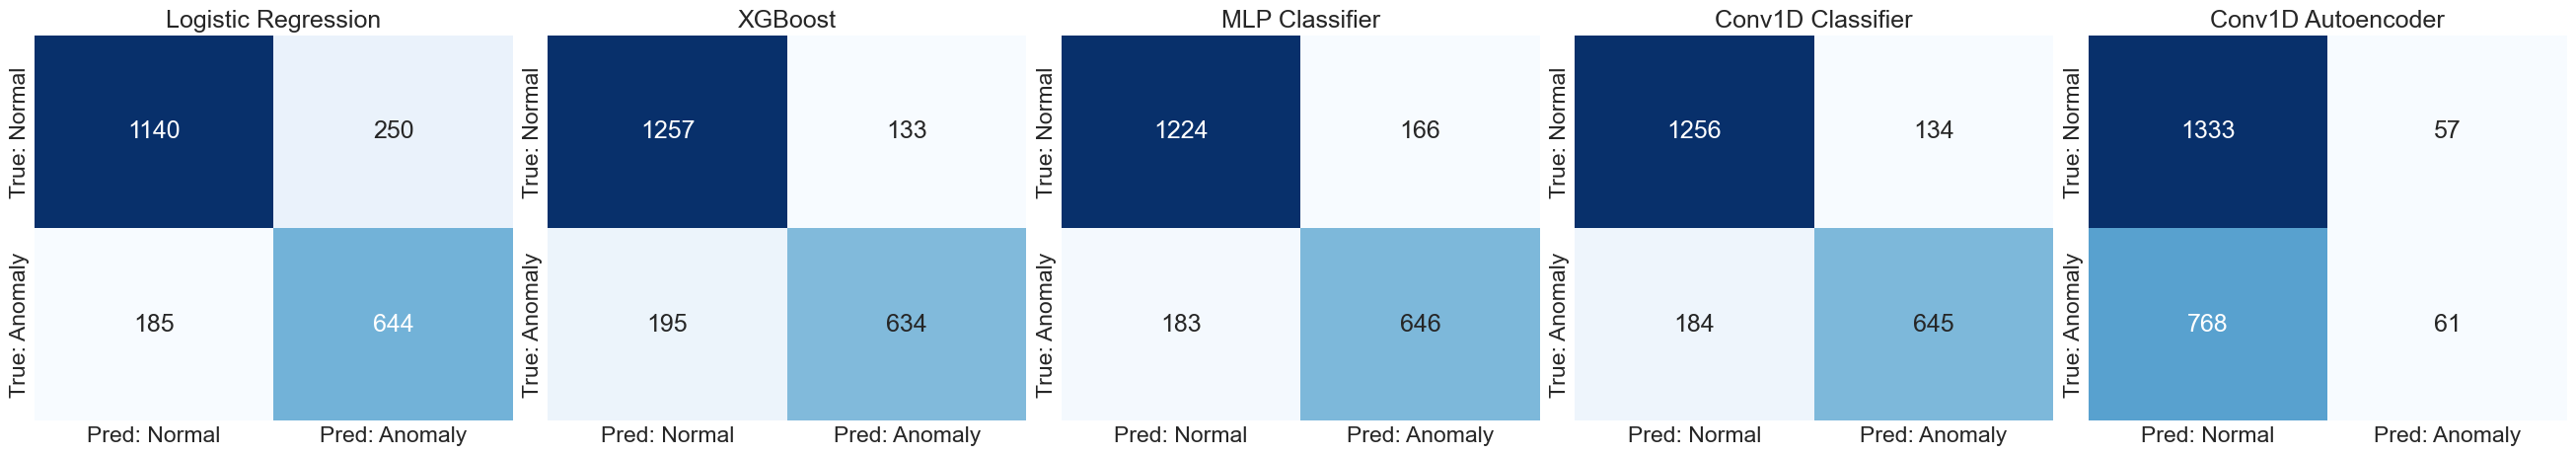

In [11]:
fig, axes = plt.subplots(1, len(binary_confusions), figsize=(5.2 * len(binary_confusions), 4.5), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (model_name, cm) in zip(axes, binary_confusions.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['Pred: Normal', 'Pred: Anomaly'],
        yticklabels=['True: Normal', 'True: Anomaly'],
    )
    ax.set_title(model_name)
plt.show()

## Multiclass confusion matrices

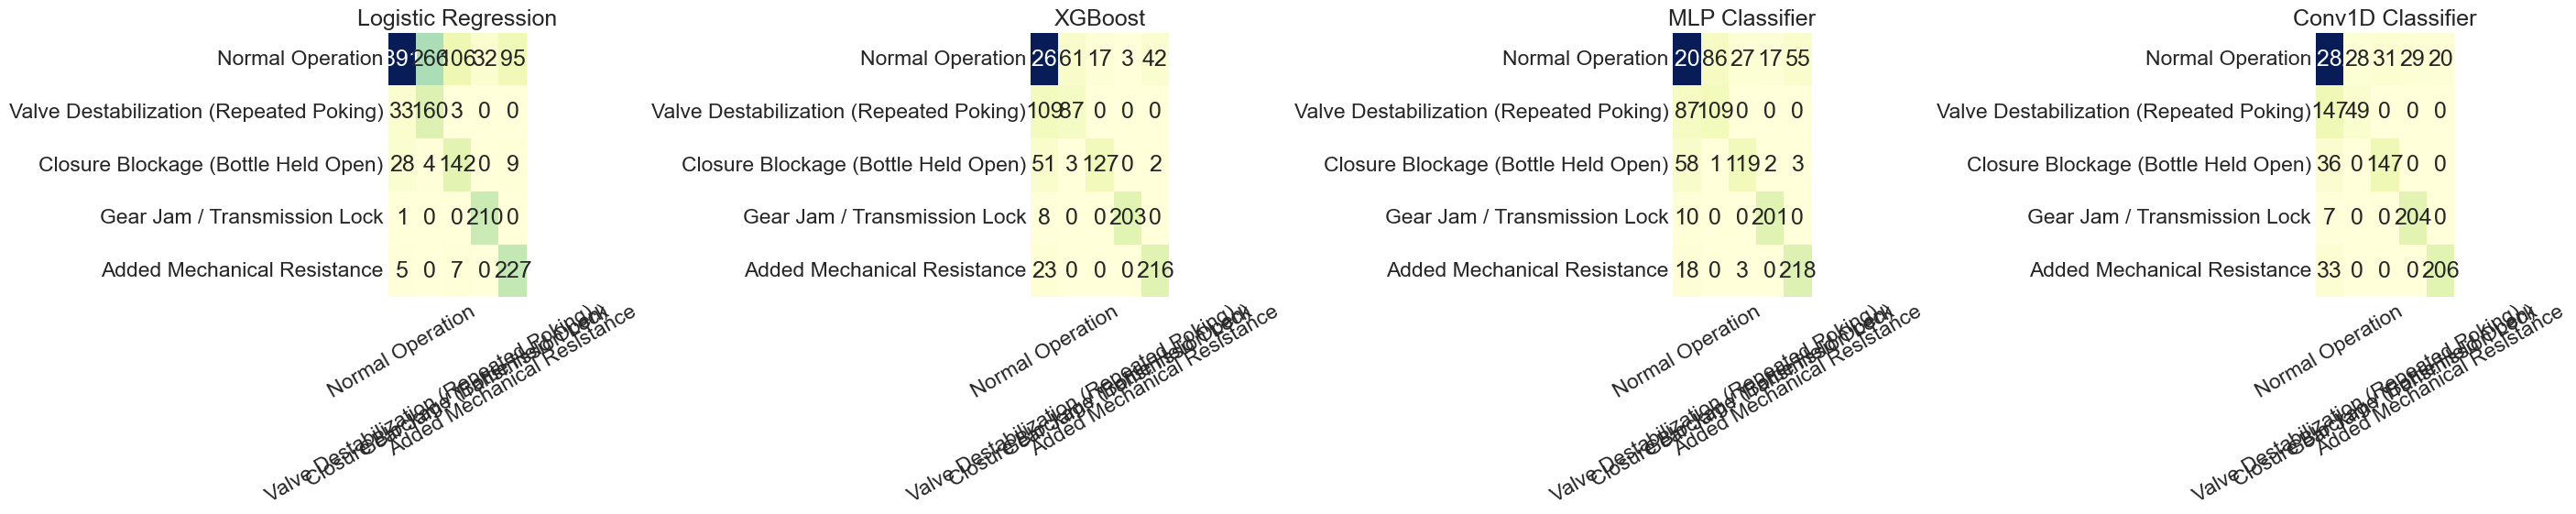

In [12]:
fig, axes = plt.subplots(1, len(multiclass_confusions), figsize=(7 * len(multiclass_confusions), 5.5), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (model_name, cm) in zip(axes, multiclass_confusions.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=False,
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_title(model_name)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.show()

## Per-class F1 across multiclass models

,model,condition_name,precision,recall,f1,support
0,Logistic Regression,Normal Operation,0.9301,0.6410,0.7589,"1,390.0000"
1,Logistic Regression,Valve Destabilization (Repeated Poking),0.3721,0.8163,0.5112,196.0000
2,Logistic Regression,Closure Blockage (Bottle Held Open),0.5504,0.7760,0.6440,183.0000
3,Logistic Regression,Gear Jam / Transmission Lock,0.8678,0.9953,0.9272,211.0000
4,Logistic Regression,Added Mechanical Resistance,0.6858,0.9498,0.7965,239.0000
5,XGBoost,Normal Operation,0.8690,0.9115,0.8897,"1,390.0000"
6,XGBoost,Valve Destabilization (Repeated Poking),0.5762,0.4439,0.5014,196.0000
7,XGBoost,Closure Blockage (Bottle Held Open),0.8819,0.6940,0.7768,183.0000
8,XGBoost,Gear Jam / Transmission Lock,0.9854,0.9621,0.9736,211.0000
9,XGBoost,Added Mechanical Resistance,0.8308,0.9038,0.8657,239.0000


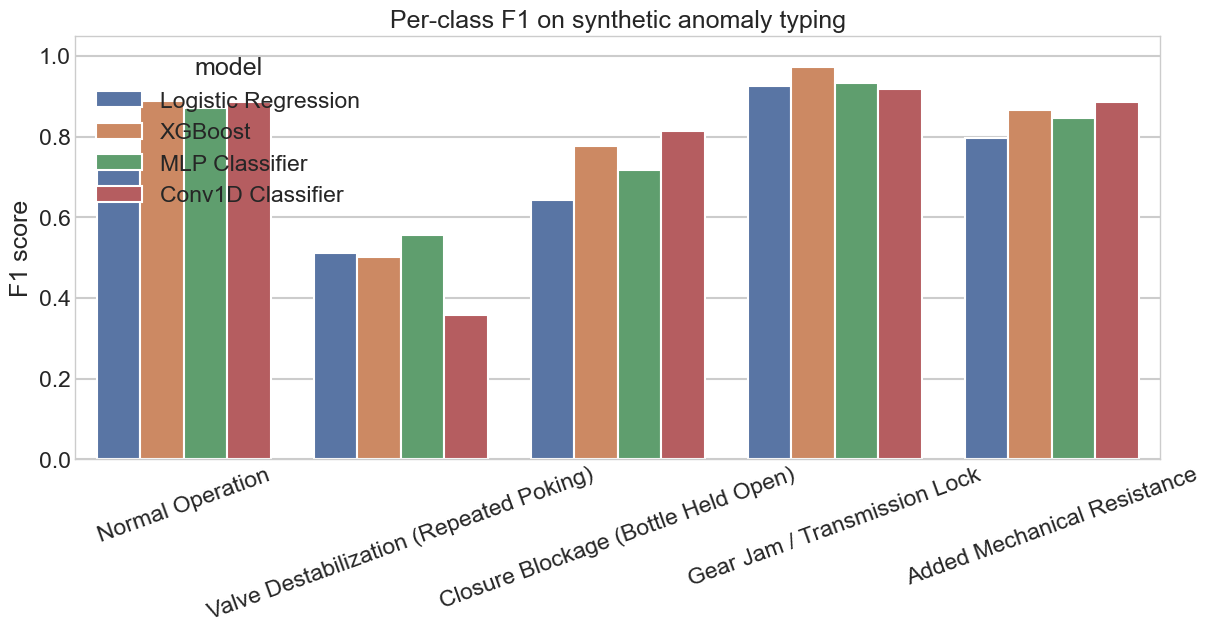

In [13]:
per_class_rows = []
for model_name, report in multiclass_reports.items():
    for class_name in CLASS_NAMES:
        per_class_rows.append(
            {
                'model': model_name,
                'condition_name': class_name,
                'precision': report[class_name]['precision'],
                'recall': report[class_name]['recall'],
                'f1': report[class_name]['f1-score'],
                'support': report[class_name]['support'],
            }
        )

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df.round(4))

plt.figure(figsize=(14, 5.5))
sns.barplot(data=per_class_df, x='condition_name', y='f1', hue='model')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.title('Per-class F1 on synthetic anomaly typing')
plt.xlabel('')
plt.ylabel('F1 score')
plt.show()

## Benchmark takeaways

In [14]:
best_binary = binary_summary_df.iloc[0]
best_multiclass = multiclass_summary_df.iloc[0]

print(
    f"Best binary detector on the synthetic test split: {best_binary['model']} "
    f"with balanced_accuracy={best_binary['balanced_accuracy']:.4f}, "
    f"f1={best_binary['f1']:.4f}, roc_auc={best_binary['roc_auc']:.4f}."
)
print(
    f"Best multiclass anomaly typer on the synthetic test split: {best_multiclass['model']} "
    f"with macro_f1={best_multiclass['macro_f1']:.4f} and balanced_accuracy={best_multiclass['balanced_accuracy']:.4f}."
)
print('The Conv1D autoencoder is only evaluated for binary anomaly detection because it reconstructs normal windows rather than predicting anomaly classes directly.')

Best binary detector on the synthetic test split: Conv1D Classifier with balanced_accuracy=0.8408, f1=0.8022, roc_auc=0.9322.
Best multiclass anomaly typer on the synthetic test split: XGBoost with macro_f1=0.8015 and balanced_accuracy=0.7830.
The Conv1D autoencoder is only evaluated for binary anomaly detection because it reconstructs normal windows rather than predicting anomaly classes directly.
